In [ ]:
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta


from config import *
from functions1 import *

In [20]:
# FX SHORT GATE

'''
Gate logic for shorting GBPCHF using returns thresholds vs carry.

We start with a minimal, easy-to-reason-about version:
- Edges only: R20 < -(carry20 + buffer20) AND R60 < -(carry60 + 3*buffer20)
- k-day consecutive confirmation
- 1-day shift for causality
- No trend filters, no statefulness, no volatility adjustments

Also provide a minimal asymmetric variant:
- Entry: require both edges (20 & 60)
- Exit: fail of 20d edge only (faster exit on rallies)
- Optional consec_on/off and optional 1-day shift
'''

import numpy as np
import pandas as pd


def standardize_fx_daily_index(s: pd.Series) -> pd.Series:
    """Ensure Mon–Fri daily bars. Your index is date-only; drop Sundays/Saturdays."""
    s = s.sort_index().astype(float).copy()
    s.index = pd.to_datetime(s.index)
    # Monday=0 ... Sunday=6; keep 0..4
    s = s[s.index.dayofweek < 5]
    # if provider emitted duplicates, keep last
    s = s[~s.index.duplicated(keep='last')]
    return s


def gbpchf_short_gate_simple(
    gbpchf: pd.Series,                 # GBPCHF (CHF per GBP), Mon–Fri
    carry_ann: float,                  # annual carry for LONG GBPCHF (r_GBP - r_CHF)
    consec: int = 3,                   # consecutive-day confirmation
    buffer20: float = 0.002,           # fixed buffer for 20d window
    shift_for_signal: bool = True,     # 1-day causal shift
) -> pd.Series:
    s = standardize_fx_daily_index(gbpchf)

    # Log returns and rolling sums
    r = np.log(s).diff()
    R20 = r.rolling(20, min_periods=20).sum()
    R60 = r.rolling(60, min_periods=60).sum()

    # Calendar-aware carry scaling by actual span (in days) of each window
    idx = pd.Series(s.index, index=s.index)
    span20_days = (idx - idx.shift(20)).dt.days
    span60_days = (idx - idx.shift(60)).dt.days
    carry20_span = carry_ann * (span20_days / 365.0)
    carry60_span = carry_ann * (span60_days / 365.0)

    # Edges: both 20d and 60d must be weak enough vs carry + buffers
    edge20 = R20 < -(carry20_span + buffer20)
    edge60 = R60 < -(carry60_span + 3.0 * buffer20)
    edges_ok = (edge20 & edge60).fillna(False)

    # k-day confirmation
    gate_consec = (
        edges_ok.astype('int8')
        .rolling(consec, min_periods=consec)
        .sum()
        .ge(consec)
        .astype(bool)
    )

    # Causal 1-day shift
    gate = gate_consec.shift(1, fill_value=False) if shift_for_signal else gate_consec
    return gate.rename("GBPCHF_short_gate_simple")


def gbpchf_short_gate_simple_asym(
    gbpchf: pd.Series,
    carry_ann: float,
    consec_on: int = 1,
    consec_off: int = 1,
    buffer20: float = 0.002,
    shift_for_signal: bool = False,
) -> pd.Series:
    """Asymmetric variant: entry needs 20&60 edges; exit on 20d edge fail."""
    s = standardize_fx_daily_index(gbpchf)

    r = np.log(s).diff()
    R20 = r.rolling(20, min_periods=20).sum()
    R60 = r.rolling(60, min_periods=60).sum()

    idx = pd.Series(s.index, index=s.index)
    span20_days = (idx - idx.shift(20)).dt.days
    span60_days = (idx - idx.shift(60)).dt.days
    carry20_span = carry_ann * (span20_days / 365.0)
    carry60_span = carry_ann * (span60_days / 365.0)

    edge20 = R20 < -(carry20_span + buffer20)
    edge60 = R60 < -(carry60_span + 3.0 * buffer20)

    entry_ok = (edge20 & edge60).fillna(False)
    exit_break = (~edge20).fillna(False)

    entry_ready = (
        entry_ok.astype('int8').rolling(consec_on, min_periods=consec_on).sum().ge(consec_on)
    )
    exit_ready = (
        exit_break.astype('int8').rolling(consec_off, min_periods=consec_off).sum().ge(consec_off)
    )

    gate = pd.Series(False, index=s.index)
    in_pos = False
    for i in range(len(s.index)):
        if not in_pos and bool(entry_ready.iloc[i]):
            in_pos = True
        elif in_pos and bool(exit_ready.iloc[i]):
            in_pos = False
        gate.iloc[i] = in_pos

    gate = gate.shift(1, fill_value=False) if shift_for_signal else gate
    return gate.rename("GBPCHF_short_gate_simple_asym")

In [21]:
ticker = 'GBPCHF.FOREX'
START = '2020-01-01'
MAX_AGE = 24
print(f'START {START}')
print(f'MAX AGE {MAX_AGE} hours')
params = {
    'from': START,  # EODHD uses from/to
    'to': today,
    'api_token': EOD_API   
}
url = (f'https://eodhd.com/api/eod/{ticker}')
# 

df = fetch_csv_robust(url, params=params, ticker=ticker,max_age=MAX_AGE)

s = sort_cols(df)
# print('original index:\n' ,s.tail(30))
# print series' days of week
# print('daysofweek:', s.index.dayofweek) 
# s_new = df[s_new.index >= pd.to_datetime(START)]
# print(s_new.describe())
# print(s_new.pct_change().describe())

# Minimal asymmetric gate: quicker exit when 20d edge fails
gateon = gbpchf_short_gate_simple_asym(
    s,
    carry_ann=0.04,
    consec_on=1,
    consec_off=1,
    buffer20=0.002,
    shift_for_signal=False,
)

# Print the full last 80 rows without truncation
# print("returned (last 80 rows):\n" + gateon.tail(80).to_string())

START 2020-01-01
MAX AGE 24 hours
GBPCHF.FOREX - using cached data


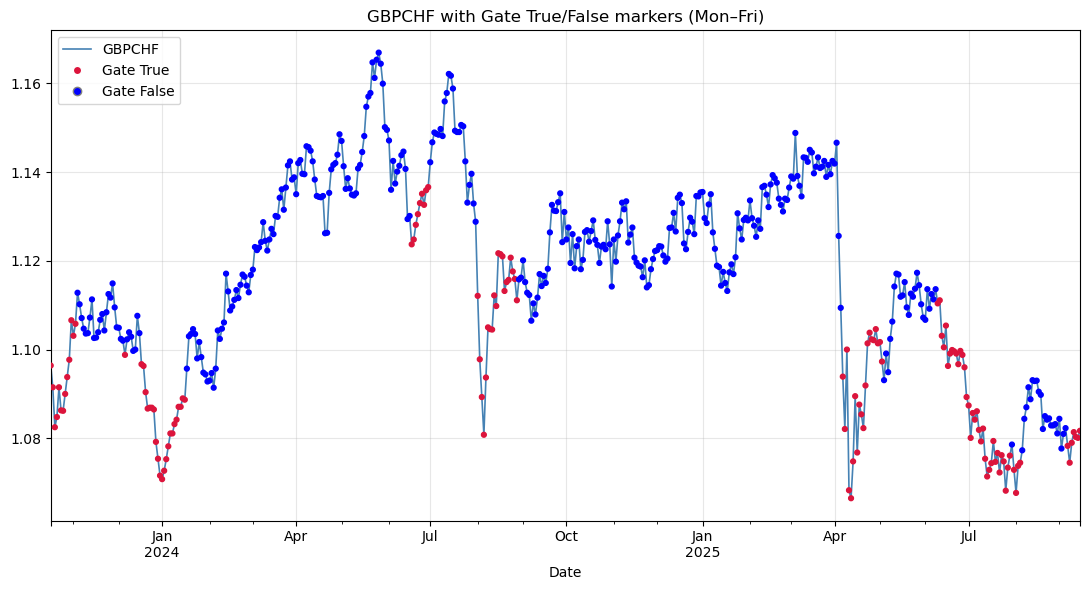

In [24]:
# Overlay gate decisions as per-day True/False markers on the price series
# Assumes you already have `s` (price series) and `gateon` (boolean series) defined

# Set how much tail to display (most recent N bars). Set to None for full history.
TAIL_BARS = 500

# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
s_std_plot = standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot

fig, ax = plt.subplots(figsize=(11, 6))

# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label='GBPCHF')

# Align gate to price index (gate is Mon–Fri too)
g = gateon.reindex(s_plot.index).fillna(False).astype(bool)

# Overlay markers colored by gate state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)

# Legend: include price and gate state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')

ax.set_title('GBPCHF with Gate True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()